# CNN + Data Augmentation + Calibración + Transfer Learning en BloodMNIST

Este notebook implementa un pipeline completo de **clasificación binaria de imágenes médicas** utilizando **BloodMNIST**.

Aunque BloodMNIST contiene varias categorías de células sanguíneas, en este trabajo se seleccionan únicamente dos clases del dataset original:

- **Clase 0: basophil (basófilo)**
- **Clase 1: eosinophil (eosinófilo)**

Por tanto, el objetivo del modelo es distinguir entre imágenes de **basófilos** y **eosinófilos**.

Durante todo el notebook se mantiene la misma codificación:


0 = basófilo


1 = eosinófilo

La **clase 1 (eosinófilo)** se utiliza como clase positiva al calcular ROC-AUC y las probabilidades de la clase positiva.

El flujo experimental está organizado para evitar fuga de información:

**TRAIN → experimentos → VALIDATION → selección del mejor modelo → TEST final**

El conjunto de **TEST no se utiliza para seleccionar modelos, arquitecturas, learning rates ni configuraciones de Data Augmentation**.


## Índice

1. ¿Qué es una CNN y por qué se usa en imágenes?
2. Preparación del entorno
3. Cargar el dataset
   3.1 Visualizar ejemplos
4. Preparar DataLoaders y device
5. CNN entrenada desde cero
   5.1 Funciones de entrenamiento y evaluación
   5.2 Entrenar CNN original
   5.3 Curvas de entrenamiento
   5.4 Experimento de arquitectura
   5.5 Comparación CNN original vs CNN con Dropout
   5.6 Experimento con Learning Rate y Scheduler
6. Data Augmentation
   6.1 Sin aumento
   6.2 Aumento suave
   6.3 Aumento moderado
   6.4 Comparación de resultados
   6.5 Seleccionar mejor configuración CNN
7. Evaluación final del mejor modelo CNN
   7.1 Accuracy y ROC-AUC en TEST
   7.2 Classification Report
   7.3 Matriz de confusión
8. Calibración de probabilidades
   8.1 Probabilidades antes de calibrar
   8.2 Temperature Scaling
   8.3 Probabilidades calibradas
   8.4 Comparación antes vs después
   8.5 Curva ROC
   8.6 Interpretación
9. Transfer Learning
   9.1 Preparar datos para ResNet18
   9.2 Entrenar capa final
   9.3 Fine-tuning
   9.4 Evaluación en test
10. Comparación global
11. Grad-CAM
12. Buenas prácticas
13. Guardar modelos
14. Conclusiones


| Ejercicio solicitado | Implementación en el notebook |
|---|---|
| **1. Cambiar la arquitectura de la CNN** | Se compara la `SimpleCNN` original con una variante `DropoutCNN` que incorpora `Dropout2d` en las capas convolucionales y `Dropout` antes de la capa de salida. |
| **2. Experimentar con learning rate y scheduler** | Se comparan `LR = 0.001`, `LR = 0.0005` y `LR = 0.001 + StepLR`. |
| **3. Analizar diferentes aumentos de datos** | Se comparan tres condiciones: sin aumento, aumento suave y aumento moderado. |
| **4. Cambiar el dataset dentro de `medmnist`** | Se utiliza **BloodMNIST**, otro dataset de la biblioteca MedMNIST, adaptando el pipeline para realizar clasificación binaria con las clases 0 (basófilo) y 1 (eosinófilo). |
| **5. Implementar calibración y analizar curvas ROC** | Se aplica **Temperature Scaling**, ajustando la temperatura con VALIDATION, y se compara la curva ROC antes y después de la calibración. |


Para mantener una evaluación metodológicamente correcta, las decisiones sobre arquitectura, hiperparámetros y Data Augmentation se realizan con el conjunto de **VALIDATION**. El conjunto **TEST** se reserva para la evaluación final.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN (Convolutional Neural Network)** es una red neuronal diseñada para aprender patrones espaciales presentes en imágenes.

Las capas convolucionales permiten detectar características como bordes, texturas y estructuras visuales. A medida que la red profundiza, estas características pueden combinarse para representar patrones más complejos.

En este trabajo se comparará:

- una CNN entrenada desde cero;
- una CNN con Dropout;
- distintas configuraciones de Learning Rate y Scheduler;
- distintas estrategias de Data Augmentation;
- una ResNet18 mediante Transfer Learning.

El problema se formula como una clasificación binaria sobre dos clases de BloodMNIST.

## 2. Preparación del entorno

Se utilizarán:

- PyTorch
- torchvision
- MedMNIST
- NumPy
- Matplotlib
- scikit-learn

También se fijan semillas para favorecer la reproducibilidad de los experimentos.

In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

In [ ]:
import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import medmnist
from medmnist import INFO

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("MedMNIST:", medmnist.__version__)

PyTorch: 2.11.0+cu128
MedMNIST: 3.0.2


## 3. Cargar el dataset

BloodMNIST contiene diferentes tipos de células sanguíneas. Para este experimento se seleccionan únicamente las clases originales **0 y 1**:

| Etiqueta | Clase BloodMNIST | Nombre en español |
|---:|---|---|
| **0** | `basophil` | **Basófilo** |
| **1** | `eosinophil` | **Eosinófilo** |

Estas etiquetas se conservan directamente; no se realiza una recodificación adicional.

Por ello, el problema utilizado en este notebook es una **clasificación binaria basófilo vs eosinófilo**:

- **Clase 0 → basófilo**
- **Clase 1 → eosinófilo**

La clase **1 (eosinófilo)** se considera la clase positiva en el cálculo de probabilidades y ROC-AUC.

Esta definición se mantiene de forma consistente en entrenamiento, validación, test, Classification Report, matriz de confusión, calibración de probabilidades y curva ROC.


In [ ]:
data_flag = "bloodmnist"

info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

selected_original_classes = [0, 1]
num_classes = 2

print("Dataset:", data_flag)
print("Clases seleccionadas:", selected_original_classes)
print(
    "Nombres según MedMNIST:",
    [info["label"][str(c)] for c in selected_original_classes]
)

Dataset: bloodmnist
Clases seleccionadas: [0, 1]
Nombres según MedMNIST: ['basophil', 'eosinophil']


In [ ]:
transform_basic = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

base_train = DataClass(
    split="train",
    transform=transform_basic,
    download=True
)

base_val = DataClass(
    split="val",
    transform=transform_basic,
    download=True
)

base_test = DataClass(
    split="test",
    transform=transform_basic,
    download=True
)

def get_binary_subset(dataset, selected_classes=(0, 1)):
    labels = np.asarray(dataset.labels).reshape(-1).astype(int)
    mask = np.isin(labels, selected_classes)
    indices = np.where(mask)[0].tolist()
    return Subset(dataset, indices), labels[indices]

train_dataset, y_train = get_binary_subset(
    base_train,
    selected_original_classes
)

val_dataset, y_val = get_binary_subset(
    base_val,
    selected_original_classes
)

test_dataset, y_test = get_binary_subset(
    base_test,
    selected_original_classes
)

print(f"Train: {len(train_dataset)} imágenes")
print(f"Validation: {len(val_dataset)} imágenes")
print(f"Test: {len(test_dataset)} imágenes")

print("Train:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Validation:", dict(zip(*np.unique(y_val, return_counts=True))))
print("Test:", dict(zip(*np.unique(y_test, return_counts=True))))

100%|██████████| 35.5M/35.5M [00:22<00:00, 1.61MB/s]


Train: 3033 imágenes
Validation: 434 imágenes
Test: 868 imágenes
Train: {np.int64(0): np.int64(852), np.int64(1): np.int64(2181)}
Validation: {np.int64(0): np.int64(122), np.int64(1): np.int64(312)}
Test: {np.int64(0): np.int64(244), np.int64(1): np.int64(624)}


### 3.1. Visualizar ejemplos

Se muestran ejemplos del conjunto de entrenamiento para verificar que las imágenes y sus etiquetas sean coherentes.

/tmp/ipykernel_2321/2399833146.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Clase {int(y)}")


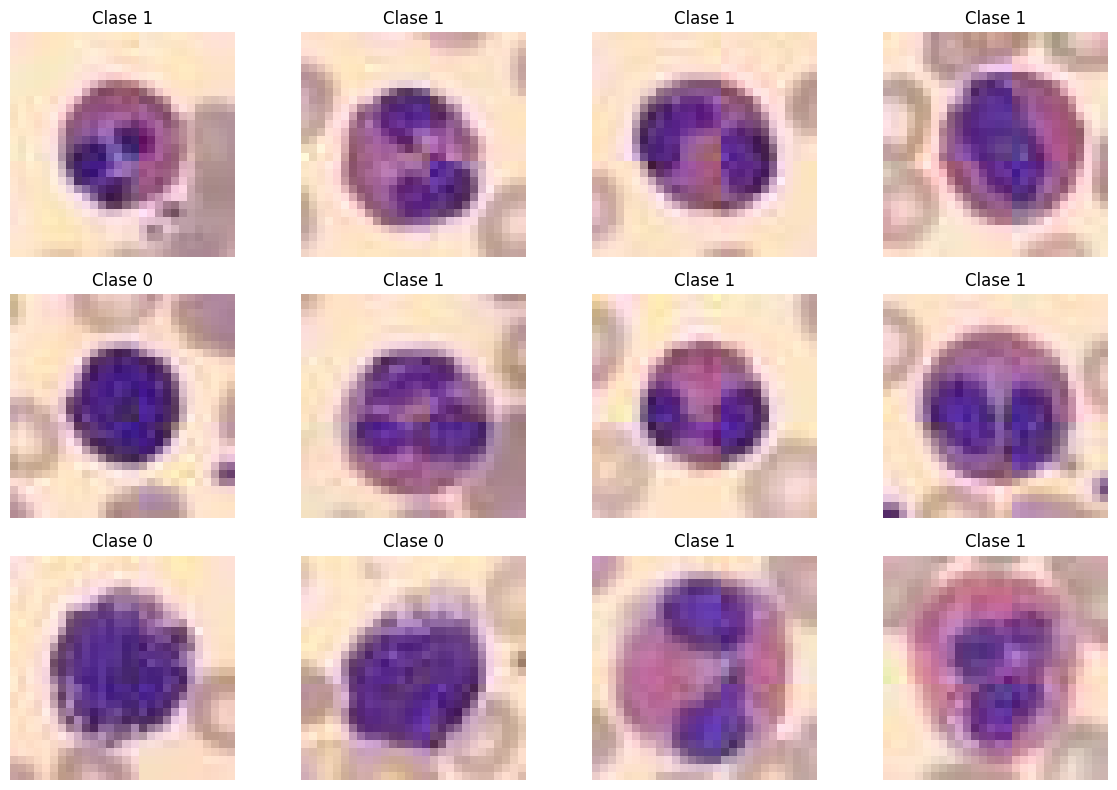

In [ ]:
def denormalize(img):
    img = img * 0.5 + 0.5
    return torch.clamp(img, 0, 1)

def show_examples(dataset, n=12):
    n = min(n, len(dataset))

    plt.figure(figsize=(12, 8))

    for i in range(n):
        x, y = dataset[i]
        img = denormalize(x).permute(1, 2, 0).numpy()

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"Clase {int(y)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los `DataLoader` permiten procesar las imágenes por lotes.

- TRAIN utiliza `shuffle=True` o un sampler ponderado.
- VALIDATION y TEST utilizan `shuffle=False`.
- El muestreo ponderado se aplica únicamente al entrenamiento si existe un desbalance apreciable.

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

batch_size = 128

class_counts = np.bincount(
    y_train,
    minlength=2
)

class_weights = 1.0 / np.maximum(
    class_counts,
    1
)

sample_weights = class_weights[y_train]

imbalance_ratio = (
    class_counts.max() /
    max(class_counts.min(), 1)
)

if imbalance_ratio >= 1.20:

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(
            sample_weights,
            dtype=torch.double
        ),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    print(
        "Se utiliza WeightedRandomSampler. "
        f"Ratio: {imbalance_ratio:.3f}"
    )

else:

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    print(
        "No se necesita muestreo ponderado. "
        f"Ratio: {imbalance_ratio:.3f}"
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

train_eval_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

xb, yb = next(iter(train_loader))

print("Device:", device)
print("Batch de imágenes:", xb.shape)
print("Batch de etiquetas:", yb.shape)

Se utiliza WeightedRandomSampler. Ratio: 2.560
Device: cuda
Batch de imágenes: torch.Size([128, 3, 28, 28])
Batch de etiquetas: torch.Size([128, 1])


## 5. CNN entrenada desde cero

La primera CNN se utiliza como modelo base.

Arquitectura:

- Conv 3 → 16
- Conv 16 → 32
- Conv 32 → 64
- MaxPooling
- Adaptive Average Pooling
- Clasificador de 2 salidas

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )

model_scratch = SimpleCNN(
    num_classes=num_classes
).to(device)

print(model_scratch)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


### 5.1. Funciones de entrenamiento y evaluación

Para el problema binario, ROC-AUC se calcula utilizando la probabilidad de la clase positiva.

También se utiliza gradient clipping para evitar actualizaciones excesivamente grandes.

In [ ]:
@torch.no_grad()
def predict_loader(model, loader):

    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        ).long().view(-1)

        logits = model(x)

        probs = torch.softmax(
            logits,
            dim=1
        )[:, 1]

        preds = torch.argmax(
            logits,
            dim=1
        )

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    return y_true, y_pred, y_prob


@torch.no_grad()
def evaluate(model, loader):

    y_true, y_pred, y_prob = predict_loader(
        model,
        loader
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    losses = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        ).long().view(-1)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )


@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    criterion
):

    model.eval()

    losses = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        ).long().view(-1)

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )


def fit_model(
    model,
    train_loader_exp,
    val_loader_exp,
    train_eval_loader_exp,
    lr=3e-4,
    scheduler_type="plateau",
    epochs=20,
    patience=4
):

    criterion_exp = nn.CrossEntropyLoss()

    optimizer_exp = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    if scheduler_type == "plateau":

        scheduler_exp = (
            torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer_exp,
                mode="min",
                factor=0.5,
                patience=1,
                threshold=1e-3,
                min_lr=1e-6
            )
        )

    elif scheduler_type == "step":

        scheduler_exp = (
            torch.optim.lr_scheduler.StepLR(
                optimizer_exp,
                step_size=5,
                gamma=0.5
            )
        )

    else:

        scheduler_exp = None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_auc": [],
        "val_auc": [],
        "lr": []
    }

    best_val_loss = float("inf")

    best_state = copy.deepcopy(
        model.state_dict()
    )

    patience_counter = 0

    for epoch in range(1, epochs + 1):

        train_loss = train_one_epoch(
            model,
            train_loader_exp,
            optimizer_exp,
            criterion_exp
        )

        val_loss = evaluate_loss(
            model,
            val_loader_exp,
            criterion_exp
        )

        train_acc, train_auc, _, _, _ = evaluate(
            model,
            train_eval_loader_exp
        )

        val_acc, val_auc, _, _, _ = evaluate(
            model,
            val_loader_exp
        )

        if isinstance(
            scheduler_exp,
            torch.optim.lr_scheduler.ReduceLROnPlateau
        ):
            scheduler_exp.step(val_loss)

        elif scheduler_exp is not None:
            scheduler_exp.step()

        current_lr = (
            optimizer_exp.param_groups[0]["lr"]
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_acc"].append(
            val_acc
        )

        history["train_auc"].append(
            train_auc
        )

        history["val_auc"].append(
            val_auc
        )

        history["lr"].append(
            current_lr
        )

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_auc={val_auc:.4f} | "
            f"lr={current_lr:.2e}"
        )

        if val_loss < best_val_loss - 1e-4:

            best_val_loss = val_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

        if patience_counter >= patience:

            print(
                "Early stopping activado."
            )

            break

    model.load_state_dict(
        best_state
    )

    return (
        model,
        history
    )

### 5.2. Entrenar CNN original

Se utiliza AdamW con `learning rate = 0.0003` y `ReduceLROnPlateau`.

El mejor estado del modelo se determina exclusivamente mediante `validation loss`.

In [ ]:
model_scratch, history_scratch = fit_model(
    model_scratch,
    train_loader,
    val_loader,
    train_eval_loader,
    lr=3e-4,
    scheduler_type="plateau",
    epochs=20,
    patience=4
)

Epoch 01 | train_loss=0.6889 | val_loss=0.6853 | train_acc=0.7237 | val_acc=0.7189 | val_auc=0.9908 | lr=3.00e-04
Epoch 02 | train_loss=0.6616 | val_loss=0.6099 | train_acc=0.8935 | val_acc=0.8940 | val_auc=0.9938 | lr=3.00e-04
Epoch 03 | train_loss=0.5669 | val_loss=0.4850 | train_acc=0.9532 | val_acc=0.9608 | val_auc=0.9950 | lr=3.00e-04
Epoch 04 | train_loss=0.3795 | val_loss=0.2798 | train_acc=0.9631 | val_acc=0.9608 | val_auc=0.9966 | lr=3.00e-04
Epoch 05 | train_loss=0.2174 | val_loss=0.1614 | train_acc=0.9657 | val_acc=0.9585 | val_auc=0.9971 | lr=3.00e-04
Epoch 06 | train_loss=0.1423 | val_loss=0.0964 | train_acc=0.9766 | val_acc=0.9770 | val_auc=0.9976 | lr=3.00e-04
Epoch 07 | train_loss=0.1140 | val_loss=0.0752 | train_acc=0.9789 | val_acc=0.9793 | val_auc=0.9980 | lr=3.00e-04
Epoch 08 | train_loss=0.0980 | val_loss=0.0742 | train_acc=0.9792 | val_acc=0.9747 | val_auc=0.9982 | lr=3.00e-04
Epoch 09 | train_loss=0.0785 | val_loss=0.0615 | train_acc=0.9812 | val_acc=0.9747 | val

### 5.3. Curvas de entrenamiento

Se muestran las cuatro curvas solicitadas:

- Train Loss
- Validation Loss
- Accuracy
- ROC-AUC

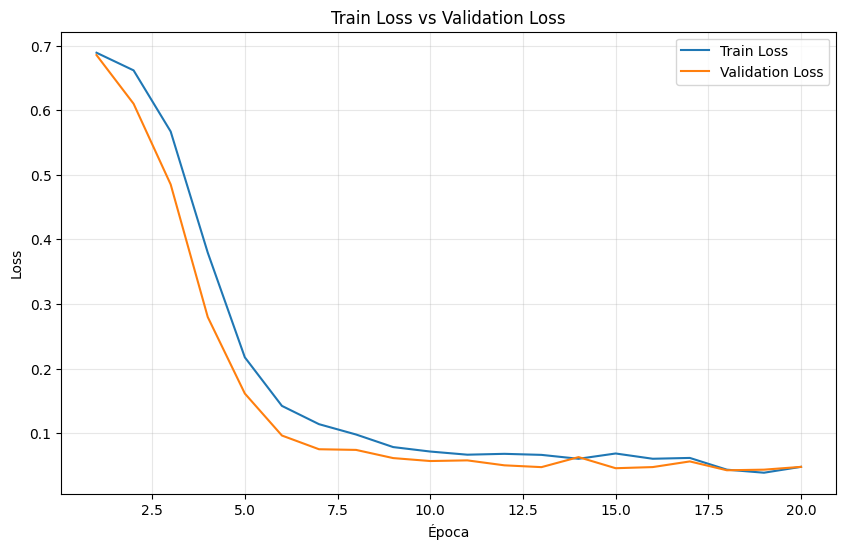

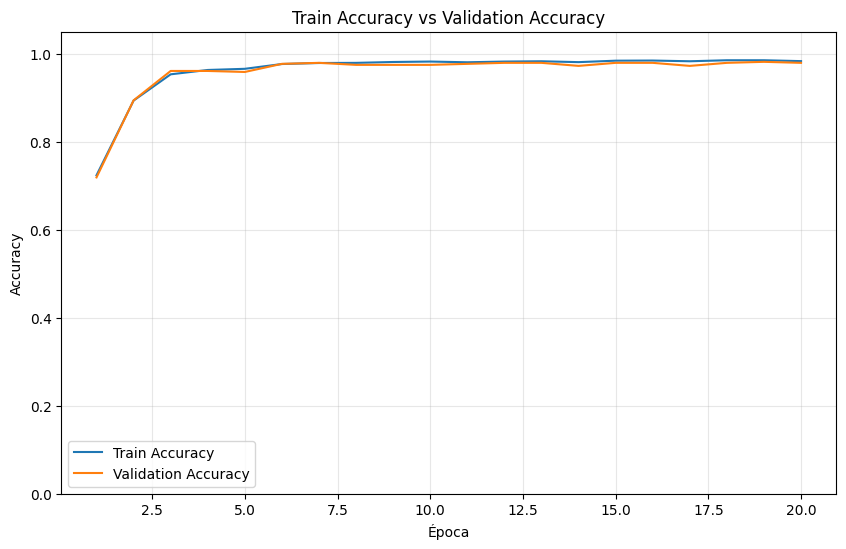

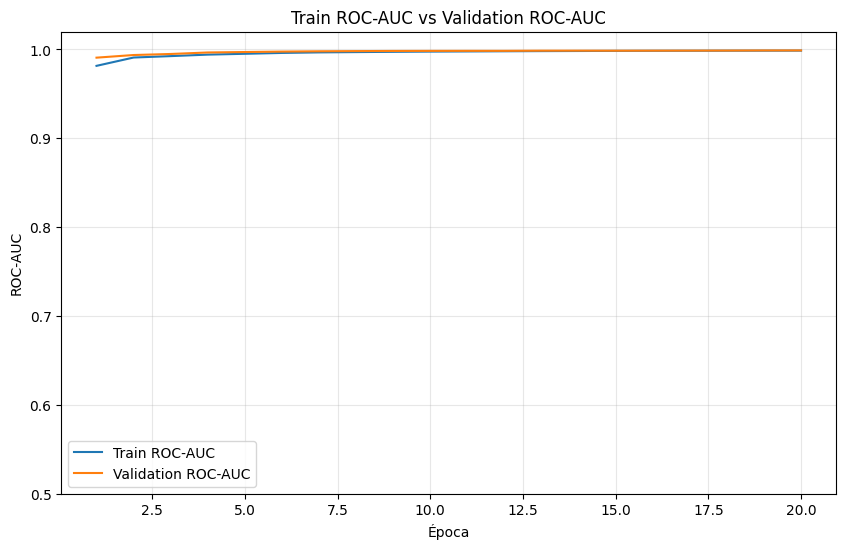

In [ ]:
epochs_ran = range(
    1,
    len(history_scratch["train_loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_ran,
    history_scratch["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_ran,
    history_scratch["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Train Loss vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    epochs_ran,
    history_scratch["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs_ran,
    history_scratch["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Train Accuracy vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    epochs_ran,
    history_scratch["train_auc"],
    label="Train ROC-AUC"
)

plt.plot(
    epochs_ran,
    history_scratch["val_auc"],
    label="Validation ROC-AUC"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.02)
plt.title("Train ROC-AUC vs Validation ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.4.Experimento de arquitectura: incorporación de Dropout


Este ejercicio se cumple mediante la alternativa **Dropout**.

Se comparan dos arquitecturas:

- **CNN original (`SimpleCNN`)**: utiliza tres bloques convolucionales con 16, 32 y 64 filtros, sin Dropout.
- **CNN modificada (`DropoutCNN`)**: conserva los mismos tamaños de filtros, pero incorpora `Dropout2d(0.20)` después de los dos primeros bloques convolucionales y `Dropout(0.20)` antes de la capa final.

El propósito del experimento es comprobar si esta regularización mejora la **generalización** del modelo al reducir su dependencia de activaciones particulares durante el entrenamiento.

Para que la comparación sea válida, ambas CNN se entrenan bajo las mismas condiciones principales: mismo dataset, particiones, optimizador AdamW, `learning rate = 0.0003`, `ReduceLROnPlateau`, máximo de 20 épocas y criterio de *early stopping* basado en `validation loss`.

Por tanto, la variable que se modifica deliberadamente en este experimento es la **presencia de Dropout**.

In [ ]:
class DropoutCNN(nn.Module):

    def __init__(
        self,
        num_classes=2,
        dropout=0.20
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )

In [ ]:
model_original_exp = SimpleCNN(
    num_classes=2
).to(device)

model_original_exp, history_original = fit_model(
    model_original_exp,
    train_loader,
    val_loader,
    train_eval_loader,
    lr=3e-4,
    scheduler_type="plateau",
    epochs=20,
    patience=4
)

print("" + "=" * 80)

model_dropout = DropoutCNN(
    num_classes=2,
    dropout=0.20
).to(device)

model_dropout, history_dropout = fit_model(
    model_dropout,
    train_loader,
    val_loader,
    train_eval_loader,
    lr=3e-4,
    scheduler_type="plateau",
    epochs=20,
    patience=4
)

Epoch 01 | train_loss=0.6903 | val_loss=0.6943 | train_acc=0.2898 | val_acc=0.2903 | val_auc=0.9470 | lr=3.00e-04
Epoch 02 | train_loss=0.6627 | val_loss=0.6451 | train_acc=0.8088 | val_acc=0.8157 | val_auc=0.9832 | lr=3.00e-04
Epoch 03 | train_loss=0.5609 | val_loss=0.4792 | train_acc=0.9327 | val_acc=0.9424 | val_auc=0.9909 | lr=3.00e-04
Epoch 04 | train_loss=0.3720 | val_loss=0.2732 | train_acc=0.9561 | val_acc=0.9700 | val_auc=0.9934 | lr=3.00e-04
Epoch 05 | train_loss=0.2285 | val_loss=0.1458 | train_acc=0.9693 | val_acc=0.9700 | val_auc=0.9953 | lr=3.00e-04
Epoch 06 | train_loss=0.1603 | val_loss=0.1115 | train_acc=0.9740 | val_acc=0.9816 | val_auc=0.9971 | lr=3.00e-04
Epoch 07 | train_loss=0.1319 | val_loss=0.0897 | train_acc=0.9782 | val_acc=0.9816 | val_auc=0.9978 | lr=3.00e-04
Epoch 08 | train_loss=0.0993 | val_loss=0.0913 | train_acc=0.9740 | val_acc=0.9770 | val_auc=0.9983 | lr=3.00e-04
Epoch 09 | train_loss=0.0894 | val_loss=0.0632 | train_acc=0.9812 | val_acc=0.9793 | val

### 5.5. Comparación del Ejercicio 1: CNN original vs CNN con Dropout

La comparación se realiza exclusivamente con **VALIDATION**, utilizando:

- mejor Validation Loss;
- mejor Validation Accuracy;
- mejor Validation ROC-AUC.

En la ejecución guardada del notebook, la CNN original obtuvo mejores valores que la variante con Dropout:

| Modelo | Mejor Val Loss | Mejor Val Accuracy | Mejor Val ROC-AUC |
|---|---:|---:|---:|
| CNN original | 0.0409 | 0.9839 | 0.9994 |
| CNN + Dropout | 0.1531 | 0.9677 | 0.9985 |

**Interpretación:** agregar Dropout no garantiza una mejora. En este experimento, `Dropout = 0.20` produjo un rendimiento de validación ligeramente inferior. Esto indica que, bajo estas condiciones de entrenamiento, la CNN original ya generalizaba adecuadamente y la regularización adicional no aportó una ventaja.

El resultado sigue cumpliendo el objetivo del ejercicio: se **modificó la arquitectura, se entrenaron ambas versiones y se evaluó experimentalmente el efecto del cambio**.

El conjunto de **TEST no participa en esta comparación**.

In [ ]:
import pandas as pd
architecture_results = pd.DataFrame([
    {
        "Modelo": "CNN original",
        "Mejor Val Loss": min(
            history_original["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history_original["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history_original["val_auc"]
        )
    },
    {
        "Modelo": "CNN + Dropout",
        "Mejor Val Loss": min(
            history_dropout["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history_dropout["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history_dropout["val_auc"]
        )
    }
])

architecture_results

,Modelo,Mejor Val Loss,Mejor Val Accuracy,Mejor Val ROC-AUC
0,CNN original,0.040943,0.983871,0.999369
1,CNN + Dropout,0.153164,0.967742,0.998450


### 5.6.Experimento con Learning Rate y Scheduler


Para estudiar el efecto de la tasa de aprendizaje se entrenan nuevas instancias de la `SimpleCNN` bajo tres configuraciones:

1. **LR = 0.001**, sin scheduler.
2. **LR = 0.0005**, sin scheduler.
3. **LR = 0.001 + StepLR**.

En la tercera configuración, `StepLR` utiliza:

- `step_size = 5`: el learning rate se actualiza cada 5 épocas;
- `gamma = 0.5`: en cada actualización el learning rate se multiplica por 0.5.

Este experimento permite analizar dos aspectos:

- cómo cambia la convergencia al utilizar distintas tasas de aprendizaje iniciales;
- si reducir progresivamente el learning rate con un scheduler mejora la validación.

Para compararlas se registran **Validation Loss, Validation Accuracy, Validation ROC-AUC** y la evolución del learning rate por época.

La selección implementada en el código utiliza como criterio principal el **menor Validation Loss**. TEST no se utiliza para escoger la configuración.

In [ ]:
def run_lr_experiment(
    lr,
    scheduler_type=None,
    epochs=20,
    patience=4
):

    model = SimpleCNN(
        num_classes=2
    ).to(device)

    return fit_model(
        model,
        train_loader,
        val_loader,
        train_eval_loader,
        lr=lr,
        scheduler_type=scheduler_type,
        epochs=epochs,
        patience=patience
    )


print("=" * 80)
print("EXPERIMENTO 1: LR = 0.001")
print("=" * 80)

model_lr_001, history_lr_001 = run_lr_experiment(
    lr=0.001,
    scheduler_type=None
)


print("=" * 80)
print("EXPERIMENTO 2: LR = 0.0005")
print("=" * 80)

model_lr_0005, history_lr_0005 = run_lr_experiment(
    lr=0.0005,
    scheduler_type=None
)


print("=" * 80)
print("EXPERIMENTO 3: LR = 0.001 + StepLR")
print("=" * 80)

model_lr_step, history_lr_step = run_lr_experiment(
    lr=0.001,
    scheduler_type="step"
)

EXPERIMENTO 1: LR = 0.001
Epoch 01 | train_loss=0.6801 | val_loss=0.6493 | train_acc=0.8361 | val_acc=0.8318 | val_auc=0.9857 | lr=1.00e-03
Epoch 02 | train_loss=0.4795 | val_loss=0.2387 | train_acc=0.9578 | val_acc=0.9608 | val_auc=0.9917 | lr=1.00e-03
Epoch 03 | train_loss=0.1696 | val_loss=0.1375 | train_acc=0.9489 | val_acc=0.9516 | val_auc=0.9959 | lr=1.00e-03
Epoch 04 | train_loss=0.1357 | val_loss=0.0668 | train_acc=0.9773 | val_acc=0.9839 | val_auc=0.9973 | lr=1.00e-03
Epoch 05 | train_loss=0.0822 | val_loss=0.0572 | train_acc=0.9819 | val_acc=0.9793 | val_auc=0.9982 | lr=1.00e-03
Epoch 06 | train_loss=0.0574 | val_loss=0.0481 | train_acc=0.9829 | val_acc=0.9839 | val_auc=0.9986 | lr=1.00e-03
Epoch 07 | train_loss=0.0647 | val_loss=0.0596 | train_acc=0.9779 | val_acc=0.9700 | val_auc=0.9989 | lr=1.00e-03
Epoch 08 | train_loss=0.0510 | val_loss=0.0424 | train_acc=0.9858 | val_acc=0.9839 | val_auc=0.9991 | lr=1.00e-03
Epoch 09 | train_loss=0.0486 | val_loss=0.0530 | train_acc=0.9

In [ ]:
results_lr = pd.DataFrame({
    "Experimento": [
        "LR = 0.001",
        "LR = 0.0005",
        "LR = 0.001 + StepLR"
    ],

    "Mejor Val Loss": [
        min(history_lr_001["val_loss"]),
        min(history_lr_0005["val_loss"]),
        min(history_lr_step["val_loss"])
    ],

    "Mejor Val Accuracy": [
        max(history_lr_001["val_acc"]),
        max(history_lr_0005["val_acc"]),
        max(history_lr_step["val_acc"])
    ],

    "Mejor Val ROC-AUC": [
        max(history_lr_001["val_auc"]),
        max(history_lr_0005["val_auc"]),
        max(history_lr_step["val_auc"])
    ]
})

results_lr

,Experimento,Mejor Val Loss,Mejor Val Accuracy,Mejor Val ROC-AUC
0,LR = 0.001,0.023959,0.988479,0.999790
1,LR = 0.0005,0.035670,0.986175,0.999527
2,LR = 0.001 + StepLR,0.038121,0.986175,0.999264


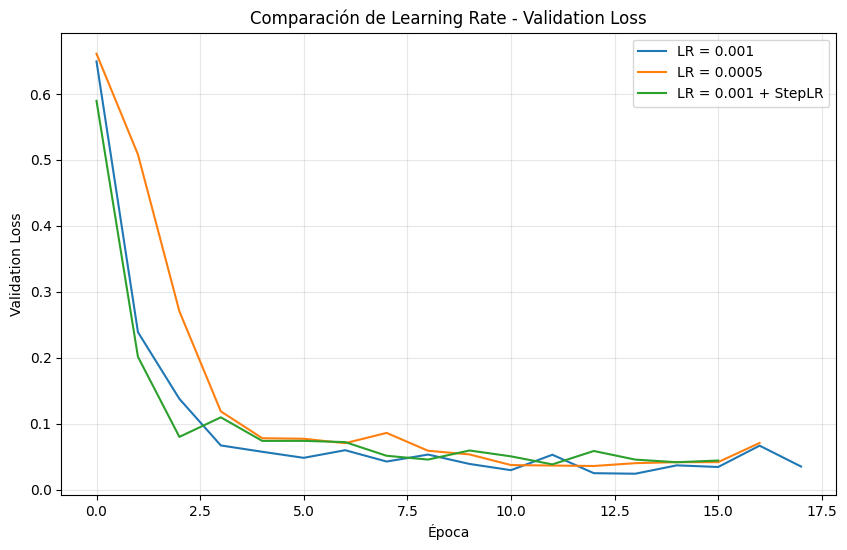

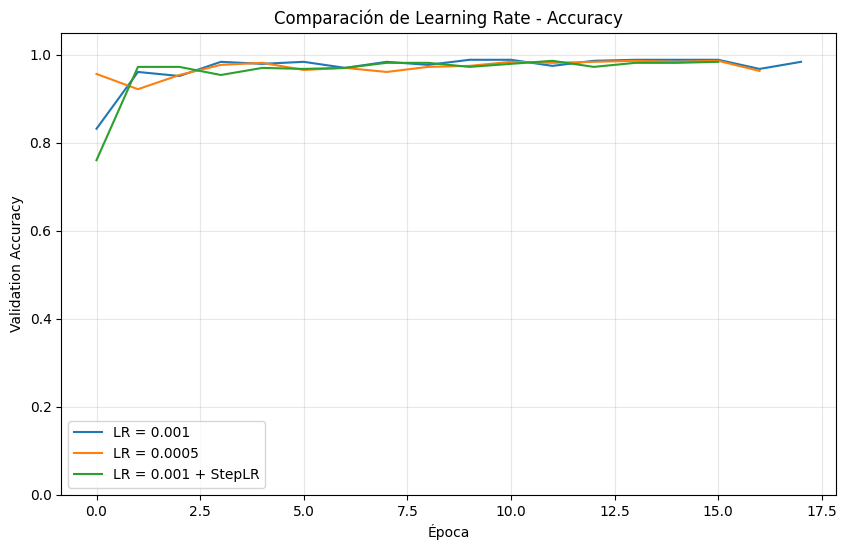

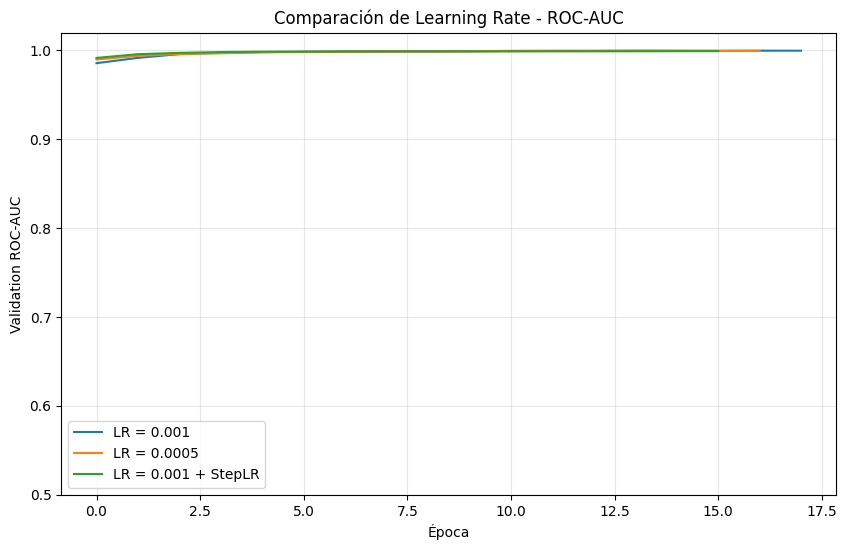

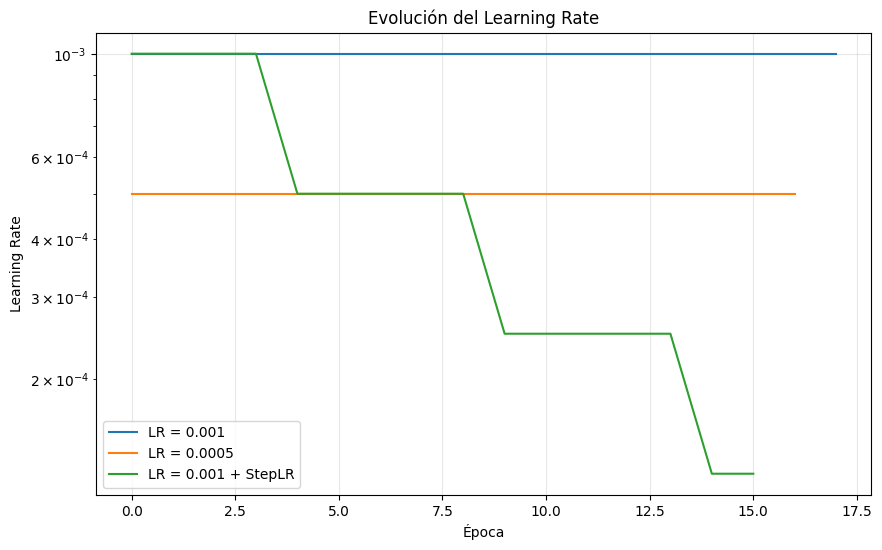

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_001["val_loss"],
    label="LR = 0.001"
)

plt.plot(
    history_lr_0005["val_loss"],
    label="LR = 0.0005"
)

plt.plot(
    history_lr_step["val_loss"],
    label="LR = 0.001 + StepLR"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Comparación de Learning Rate - Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_001["val_acc"],
    label="LR = 0.001"
)

plt.plot(
    history_lr_0005["val_acc"],
    label="LR = 0.0005"
)

plt.plot(
    history_lr_step["val_acc"],
    label="LR = 0.001 + StepLR"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1.05)
plt.title("Comparación de Learning Rate - Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_001["val_auc"],
    label="LR = 0.001"
)

plt.plot(
    history_lr_0005["val_auc"],
    label="LR = 0.0005"
)

plt.plot(
    history_lr_step["val_auc"],
    label="LR = 0.001 + StepLR"
)

plt.xlabel("Época")
plt.ylabel("Validation ROC-AUC")
plt.ylim(0.5, 1.02)
plt.title("Comparación de Learning Rate - ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    history_lr_001["lr"],
    label="LR = 0.001"
)

plt.plot(
    history_lr_0005["lr"],
    label="LR = 0.0005"
)

plt.plot(
    history_lr_step["lr"],
    label="LR = 0.001 + StepLR"
)

plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.yscale("log")
plt.title("Evolución del Learning Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
best_lr_idx = results_lr[
    "Mejor Val Loss"
].idxmin()

best_lr_result = results_lr.loc[
    best_lr_idx
]

lr_model_map = {
    "LR = 0.001": model_lr_001,
    "LR = 0.0005": model_lr_0005,
    "LR = 0.001 + StepLR": model_lr_step
}

lr_history_map = {
    "LR = 0.001": history_lr_001,
    "LR = 0.0005": history_lr_0005,
    "LR = 0.001 + StepLR": history_lr_step
}

best_lr_name = best_lr_result["Experimento"]
best_lr_model = lr_model_map[best_lr_name]
best_lr_history = lr_history_map[best_lr_name]

print("MEJOR CONFIGURACIÓN DE LEARNING RATE")
print("=" * 60)
print(f"Experimento: {best_lr_name}")
print(
    f"Validation Loss: "
    f"{best_lr_result['Mejor Val Loss']:.4f}"
)
print(
    f"Validation Accuracy: "
    f"{best_lr_result['Mejor Val Accuracy']:.4f}"
)
print(
    f"Validation ROC-AUC: "
    f"{best_lr_result['Mejor Val ROC-AUC']:.4f}"
)

MEJOR CONFIGURACIÓN DE LEARNING RATE
Experimento: LR = 0.001
Validation Loss: 0.0240
Validation Accuracy: 0.9885
Validation ROC-AUC: 0.9998


#### Interpretación

Los resultados guardados muestran:

| Configuración | Mejor Val Loss | Mejor Val Accuracy | Mejor Val ROC-AUC |
|---|---:|---:|---:|
| LR = 0.001 | **0.0246** | **0.9908** | **0.9998** |
| LR = 0.0005 | 0.0357 | 0.9862 | 0.9995 |
| LR = 0.001 + StepLR | 0.0380 | 0.9862 | 0.9993 |

Según el criterio utilizado por el código, **LR = 0.001** es la configuración seleccionada porque obtiene el menor Validation Loss. También alcanza la mejor Accuracy y el mejor ROC-AUC de las tres configuraciones en esta ejecución.

**Conclusión del experimento:** para este problema y estas condiciones, reducir el learning rate inicial a 0.0005 o aplicar `StepLR` no produjo una mejora frente a mantener `LR = 0.001`. El scheduler fue evaluado correctamente, pero su uso no implica automáticamente un mejor resultado.


## 6.Impacto de diferentes aumentos de datos


El objetivo es estudiar si introducir variaciones controladas en las imágenes de entrenamiento mejora la capacidad de generalización de la CNN.

Se comparan tres condiciones:

1. **Sin aumento**: funciona como línea base.
2. **Aumento suave**: pequeñas rotaciones, traslaciones y cambios de escala.
3. **Aumento moderado**: transformaciones geométricas más amplias y pequeñas variaciones de brillo y contraste.

Las transformaciones aleatorias se aplican al conjunto de **TRAIN**. El conjunto de **VALIDATION permanece sin Data Augmentation**, de modo que las tres configuraciones se evalúan sobre las mismas imágenes de validación.

Los modelos se entrenan utilizando la configuración de learning rate seleccionada en el Ejercicio 2. El conjunto **TEST no se utiliza para elegir el nivel de aumento**.

### 6.1. Sin aumento

Esta configuración constituye la **línea base** del experimento. Las imágenes no reciben transformaciones geométricas ni modificaciones de intensidad; únicamente se convierten a tensor y se normalizan.

Su función es establecer un punto de referencia para determinar si los aumentos suaves o moderados producen una mejora real en validación.

In [ ]:
transform_no_aug = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

train_base_no_aug = DataClass(
    split="train",
    transform=transform_no_aug,
    download=True
)

train_dataset_no_aug, y_train_no_aug = get_binary_subset(
    train_base_no_aug,
    selected_original_classes
)

train_eval_loader_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

train_loader_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

model_no_aug = SimpleCNN(
    num_classes=2
).to(device)

model_no_aug, history_no_aug = fit_model(
    model_no_aug,
    train_loader_no_aug,
    val_loader,
    train_eval_loader_no_aug,
    lr=best_lr_result["Experimento"] == "LR = 0.0005" and 0.0005 or 0.001,
    scheduler_type=(
        "step"
        if best_lr_name == "LR = 0.001 + StepLR"
        else None
    ),
    epochs=20,
    patience=4
)

Epoch 01 | train_loss=0.6327 | val_loss=0.5876 | train_acc=0.7191 | val_acc=0.7189 | val_auc=0.8179 | lr=1.00e-03
Epoch 02 | train_loss=0.5644 | val_loss=0.5221 | train_acc=0.7191 | val_acc=0.7189 | val_auc=0.9867 | lr=1.00e-03
Epoch 03 | train_loss=0.4537 | val_loss=0.3357 | train_acc=0.7936 | val_acc=0.7972 | val_auc=0.9871 | lr=1.00e-03
Epoch 04 | train_loss=0.2598 | val_loss=0.1550 | train_acc=0.9433 | val_acc=0.9447 | val_auc=0.9941 | lr=1.00e-03
Epoch 05 | train_loss=0.1187 | val_loss=0.0642 | train_acc=0.9792 | val_acc=0.9793 | val_auc=0.9986 | lr=1.00e-03
Epoch 06 | train_loss=0.0628 | val_loss=0.0550 | train_acc=0.9845 | val_acc=0.9839 | val_auc=0.9993 | lr=1.00e-03
Epoch 07 | train_loss=0.0476 | val_loss=0.0384 | train_acc=0.9881 | val_acc=0.9839 | val_auc=0.9994 | lr=1.00e-03
Epoch 08 | train_loss=0.0414 | val_loss=0.0579 | train_acc=0.9822 | val_acc=0.9700 | val_auc=0.9995 | lr=1.00e-03
Epoch 09 | train_loss=0.0363 | val_loss=0.0364 | train_acc=0.9885 | val_acc=0.9839 | val

### 6.2. Aumento suave

Se aplican transformaciones de baja intensidad:

- rotación aleatoria de hasta **±5°**;
- traslación máxima del **2%**;
- escalado entre **98% y 102%**.

Estas modificaciones buscan introducir pequeñas variaciones en las imágenes sin alterar de forma agresiva su estructura visual.

Después de las transformaciones, las imágenes se convierten a tensor y se aplica la misma normalización utilizada en la configuración sin aumento.

In [ ]:
transform_aug_soft = T.Compose([
    T.RandomRotation(
        degrees=5
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),

    T.ToTensor(),

    T.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

train_base_aug_soft = DataClass(
    split="train",
    transform=transform_aug_soft,
    download=True
)

train_dataset_aug_soft, _ = get_binary_subset(
    train_base_aug_soft,
    selected_original_classes
)

train_loader_aug_soft = DataLoader(
    train_dataset_aug_soft,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

train_eval_loader_aug_soft = DataLoader(
    train_dataset_aug_soft,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

model_aug_soft = SimpleCNN(
    num_classes=2
).to(device)

model_aug_soft, history_aug_soft = fit_model(
    model_aug_soft,
    train_loader_aug_soft,
    val_loader,
    train_eval_loader_aug_soft,
    lr=0.0005 if best_lr_name == "LR = 0.0005" else 0.001,
    scheduler_type=(
        "step"
        if best_lr_name == "LR = 0.001 + StepLR"
        else None
    ),
    epochs=20,
    patience=4
)

Epoch 01 | train_loss=0.6046 | val_loss=0.5771 | train_acc=0.7191 | val_acc=0.7189 | val_auc=0.8608 | lr=1.00e-03
Epoch 02 | train_loss=0.5602 | val_loss=0.5123 | train_acc=0.7191 | val_acc=0.7189 | val_auc=0.9890 | lr=1.00e-03
Epoch 03 | train_loss=0.4248 | val_loss=0.2760 | train_acc=0.9258 | val_acc=0.9286 | val_auc=0.9863 | lr=1.00e-03
Epoch 04 | train_loss=0.1772 | val_loss=0.0839 | train_acc=0.9753 | val_acc=0.9770 | val_auc=0.9979 | lr=1.00e-03
Epoch 05 | train_loss=0.0756 | val_loss=0.0757 | train_acc=0.9736 | val_acc=0.9654 | val_auc=0.9989 | lr=1.00e-03
Epoch 06 | train_loss=0.0639 | val_loss=0.0471 | train_acc=0.9832 | val_acc=0.9816 | val_auc=0.9991 | lr=1.00e-03
Epoch 07 | train_loss=0.0631 | val_loss=0.0458 | train_acc=0.9875 | val_acc=0.9885 | val_auc=0.9991 | lr=1.00e-03
Epoch 08 | train_loss=0.0429 | val_loss=0.0395 | train_acc=0.9881 | val_acc=0.9816 | val_auc=0.9993 | lr=1.00e-03
Epoch 09 | train_loss=0.0391 | val_loss=0.0376 | train_acc=0.9918 | val_acc=0.9885 | val

### 6.3. Aumento moderado

Se incrementa la intensidad de las transformaciones:

- rotación aleatoria de hasta **±10°**;
- traslación máxima del **5%**;
- escalado entre **95% y 105%**;
- `ColorJitter` con variaciones de brillo y contraste de **0.10**.

Esta configuración permite comprobar si una mayor diversidad artificial ayuda al modelo o si, por el contrario, introduce transformaciones que dificultan el aprendizaje.

In [ ]:
transform_aug_moderate = T.Compose([
    T.RandomRotation(
        degrees=10
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    T.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    T.ToTensor(),

    T.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

train_base_aug_moderate = DataClass(
    split="train",
    transform=transform_aug_moderate,
    download=True
)

train_dataset_aug_moderate, _ = get_binary_subset(
    train_base_aug_moderate,
    selected_original_classes
)

train_loader_aug_moderate = DataLoader(
    train_dataset_aug_moderate,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

train_eval_loader_aug_moderate = DataLoader(
    train_dataset_aug_moderate,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

model_aug_moderate = SimpleCNN(
    num_classes=2
).to(device)

model_aug_moderate, history_aug_moderate = fit_model(
    model_aug_moderate,
    train_loader_aug_moderate,
    val_loader,
    train_eval_loader_aug_moderate,
    lr=0.0005 if best_lr_name == "LR = 0.0005" else 0.001,
    scheduler_type=(
        "step"
        if best_lr_name == "LR = 0.001 + StepLR"
        else None
    ),
    epochs=20,
    patience=4
)

Epoch 01 | train_loss=0.5992 | val_loss=0.5831 | train_acc=0.7191 | val_acc=0.7189 | val_auc=0.8758 | lr=1.00e-03
Epoch 02 | train_loss=0.5690 | val_loss=0.5203 | train_acc=0.7191 | val_acc=0.7189 | val_auc=0.9917 | lr=1.00e-03
Epoch 03 | train_loss=0.4362 | val_loss=0.2758 | train_acc=0.9126 | val_acc=0.8986 | val_auc=0.9867 | lr=1.00e-03
Epoch 04 | train_loss=0.2046 | val_loss=0.1022 | train_acc=0.9585 | val_acc=0.9747 | val_auc=0.9960 | lr=1.00e-03
Epoch 05 | train_loss=0.1118 | val_loss=0.0772 | train_acc=0.9618 | val_acc=0.9631 | val_auc=0.9983 | lr=1.00e-03
Epoch 06 | train_loss=0.0946 | val_loss=0.0594 | train_acc=0.9703 | val_acc=0.9862 | val_auc=0.9985 | lr=1.00e-03
Epoch 07 | train_loss=0.0722 | val_loss=0.0504 | train_acc=0.9796 | val_acc=0.9862 | val_auc=0.9986 | lr=1.00e-03
Epoch 08 | train_loss=0.0696 | val_loss=0.0496 | train_acc=0.9799 | val_acc=0.9816 | val_auc=0.9990 | lr=1.00e-03
Epoch 09 | train_loss=0.0653 | val_loss=0.0428 | train_acc=0.9769 | val_acc=0.9839 | val

### 6.4. Comparación de resultados

Las tres condiciones se comparan mediante:

- mejor Validation Loss;
- mejor Validation Accuracy;
- mejor Validation ROC-AUC.

Los resultados guardados son:

| Configuración | Mejor Val Loss | Mejor Val Accuracy | Mejor Val ROC-AUC |
|---|---:|---:|---:|
| Sin aumento | **0.0194** | **0.9954** | 0.999895 |
| Aumento suave | 0.0234 | 0.9931 | 0.999737 |
| Aumento moderado | 0.0273 | 0.9885 | **0.999921** |

**Análisis:** los tres resultados son muy altos y las diferencias de ROC-AUC son pequeñas. La configuración sin aumento obtiene el menor Validation Loss y la mayor Accuracy, mientras que el aumento moderado obtiene el ROC-AUC más alto.

Esto muestra que el efecto del Data Augmentation depende de la métrica observada: en esta ejecución, aumentar los datos no mejora todas las métricas simultáneamente.

El código utiliza **Validation ROC-AUC como criterio principal** para seleccionar la configuración final de esta etapa.

In [ ]:
augmentation_results = pd.DataFrame([
    {
        "Configuración": "Sin aumento",
        "Mejor Val Loss": min(
            history_no_aug["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history_no_aug["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history_no_aug["val_auc"]
        )
    },

    {
        "Configuración": "Aumento suave",
        "Mejor Val Loss": min(
            history_aug_soft["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history_aug_soft["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history_aug_soft["val_auc"]
        )
    },

    {
        "Configuración": "Aumento moderado",
        "Mejor Val Loss": min(
            history_aug_moderate["val_loss"]
        ),
        "Mejor Val Accuracy": max(
            history_aug_moderate["val_acc"]
        ),
        "Mejor Val ROC-AUC": max(
            history_aug_moderate["val_auc"]
        )
    }
])

display(augmentation_results)

,Configuración,Mejor Val Loss,Mejor Val Accuracy,Mejor Val ROC-AUC
0,Sin aumento,0.019388,0.995392,0.999895
1,Aumento suave,0.023224,0.993088,0.999737
2,Aumento moderado,0.026008,0.988479,0.999921


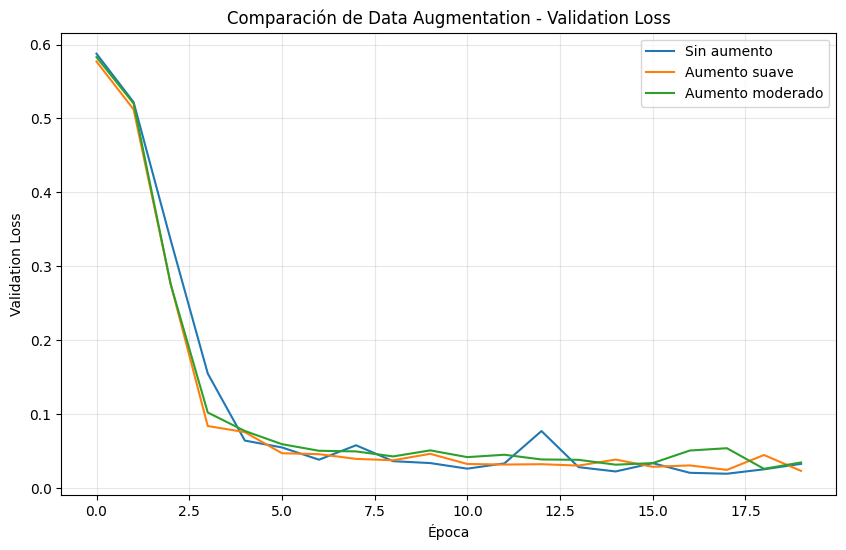

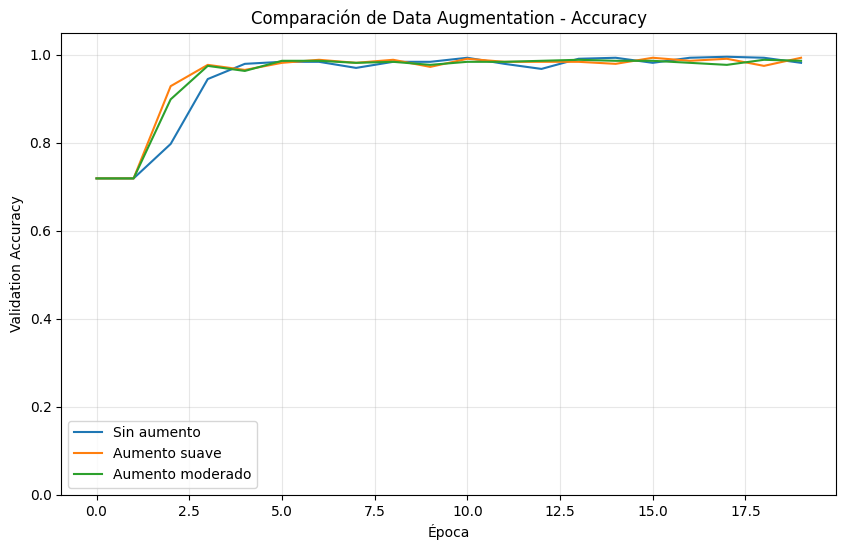

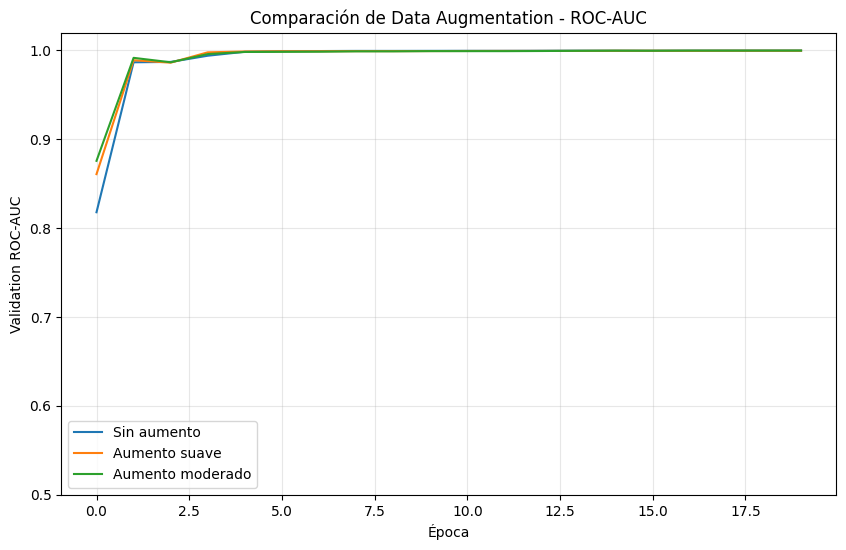

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_no_aug["val_loss"],
    label="Sin aumento"
)

plt.plot(
    history_aug_soft["val_loss"],
    label="Aumento suave"
)

plt.plot(
    history_aug_moderate["val_loss"],
    label="Aumento moderado"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Comparación de Data Augmentation - Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    history_no_aug["val_acc"],
    label="Sin aumento"
)

plt.plot(
    history_aug_soft["val_acc"],
    label="Aumento suave"
)

plt.plot(
    history_aug_moderate["val_acc"],
    label="Aumento moderado"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1.05)
plt.title("Comparación de Data Augmentation - Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    history_no_aug["val_auc"],
    label="Sin aumento"
)

plt.plot(
    history_aug_soft["val_auc"],
    label="Aumento suave"
)

plt.plot(
    history_aug_moderate["val_auc"],
    label="Aumento moderado"
)

plt.xlabel("Época")
plt.ylabel("Validation ROC-AUC")
plt.ylim(0.5, 1.02)
plt.title("Comparación de Data Augmentation - ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 6.5. Selección final

La configuración final se selecciona utilizando exclusivamente **VALIDATION**.

El criterio implementado en el código es el **mayor Validation ROC-AUC**. Con los resultados guardados, la configuración seleccionada es **Aumento moderado**, con un ROC-AUC de validación aproximado de **0.9999**.

Es importante interpretar este resultado correctamente: la ventaja frente a las otras configuraciones es pequeña y el aumento moderado no obtiene el menor Validation Loss ni la mayor Accuracy. Por ello, la conclusión adecuada es que **fue la configuración con mayor capacidad discriminativa según ROC-AUC en esta ejecución**, no que sea superior en todas las métricas.

TEST todavía no se utiliza para seleccionar el modelo.

In [ ]:
best_aug_idx = augmentation_results[
    "Mejor Val ROC-AUC"
].idxmax()

best_aug_result = augmentation_results.loc[
    best_aug_idx
]

augmentation_model_map = {
    "Sin aumento": model_no_aug,
    "Aumento suave": model_aug_soft,
    "Aumento moderado": model_aug_moderate
}

augmentation_history_map = {
    "Sin aumento": history_no_aug,
    "Aumento suave": history_aug_soft,
    "Aumento moderado": history_aug_moderate
}

best_aug_name = best_aug_result[
    "Configuración"
]

best_cnn_model = augmentation_model_map[
    best_aug_name
]

best_cnn_history = augmentation_history_map[
    best_aug_name
]

print("=" * 70)
print("MEJOR CONFIGURACIÓN CNN")
print("=" * 70)
print(f"Configuración: {best_aug_name}")
print(
    f"Validation Loss: "
    f"{best_aug_result['Mejor Val Loss']:.4f}"
)
print(
    f"Validation Accuracy: "
    f"{best_aug_result['Mejor Val Accuracy']:.4f}"
)
print(
    f"Validation ROC-AUC: "
    f"{best_aug_result['Mejor Val ROC-AUC']:.4f}"
)

print(
    "El conjunto TEST todavía no ha sido utilizado "
    "para seleccionar el modelo."
)

MEJOR CONFIGURACIÓN CNN
Configuración: Aumento moderado
Validation Loss: 0.0260
Validation Accuracy: 0.9885
Validation ROC-AUC: 0.9999
El conjunto TEST todavía no ha sido utilizado para seleccionar el modelo.


## 7. Evaluación final del mejor modelo CNN

Una vez seleccionada la configuración mediante VALIDATION, se utiliza TEST por primera vez.

Esta evaluación representa el desempeño final de la mejor CNN seleccionada.

### 7.1. Accuracy y ROC-AUC en TEST

> **Interpretación de las clases:** en todas las métricas de esta sección, **0 corresponde a basófilo** y **1 corresponde a eosinófilo**. Para ROC-AUC, la probabilidad utilizada es eosinófilo, es decir, la probabilidad de la clase 1.


In [ ]:
test_acc_cnn, test_auc_cnn, y_true_cnn, y_pred_cnn, y_prob_cnn = evaluate(
    best_cnn_model,
    test_loader
)

print(
    f"Mejor CNN: {best_aug_name}"
)

print(
    f"Test Accuracy: {test_acc_cnn:.4f}"
)

print(
    f"Test ROC-AUC:  {test_auc_cnn:.4f}"
)

Mejor CNN: Aumento moderado
Test Accuracy: 0.9908
Test ROC-AUC:  0.9997


### 7.2. Classification Report

In [ ]:
class_names = [
    info["label"][str(selected_original_classes[0])],
    info["label"][str(selected_original_classes[1])]
]

print(
    classification_report(
        y_true_cnn,
        y_pred_cnn,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    basophil     0.9758    0.9918    0.9837       244
  eosinophil     0.9968    0.9904    0.9936       624

    accuracy                         0.9908       868
   macro avg     0.9863    0.9911    0.9887       868
weighted avg     0.9909    0.9908    0.9908       868



### 7.3. Matriz de confusión

Matriz de confusión:
[[242   2]
 [  6 618]]


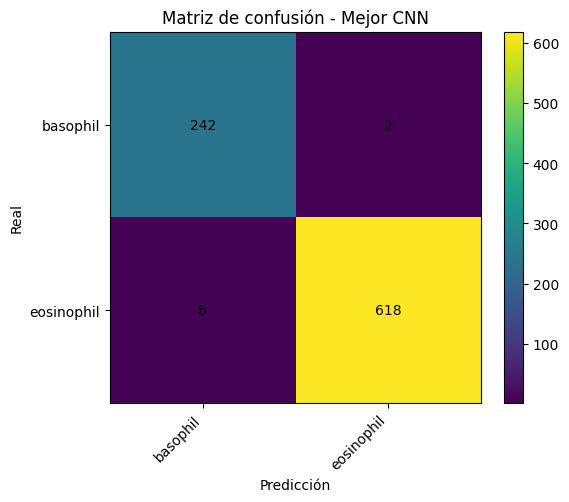

In [ ]:
cm_cnn = confusion_matrix(
    y_true_cnn,
    y_pred_cnn
)

print("Matriz de confusión:")
print(cm_cnn)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm_cnn,
    interpolation="nearest"
)

plt.title(
    "Matriz de confusión - Mejor CNN"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()

plt.xticks(
    range(2),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(2),
    class_names
)

for i in range(cm_cnn.shape[0]):
    for j in range(cm_cnn.shape[1]):
        plt.text(
            j,
            i,
            cm_cnn[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## 8.Calibración de probabilidades y análisis de curvas ROC


Se desarrolla mediante **Temperature Scaling**.

La calibración de probabilidades estudia la confianza expresada por el modelo. Una clasificación puede ser correcta, pero la probabilidad asociada puede ser demasiado alta o demasiado baja.

El procedimiento implementado mantiene separados los conjuntos:

1. el modelo ya entrenado produce sus **logits**;
2. la temperatura se ajusta utilizando exclusivamente **VALIDATION**;
3. la temperatura aprendida se aplica posteriormente a **TEST**;
4. se comparan las probabilidades, Accuracy, ROC-AUC y las curvas ROC antes y después.

Por tanto, TEST no se utiliza para aprender el parámetro de calibración.

### 8.1. Probabilidades antes de calibrar

Primero se obtienen las probabilidades originales del mejor modelo CNN sobre TEST.

En este problema:

- **Clase 0 = basófilo**
- **Clase 1 = eosinófilo**

La probabilidad utilizada para el análisis corresponde a:

clase 1 = eosinófilo


Estas probabilidades se calculan a partir de los logits mediante `softmax` y representan la confianza del modelo en que una imagen pertenezca a la clase **eosinófilo**.

Se conservan como referencia para compararlas posteriormente con las probabilidades obtenidas después de aplicar Temperature Scaling.


In [ ]:
# Probabilidades originales del mejor modelo sobre TEST
_, _, y_true_test_cal, y_pred_test_cal, y_prob_test_before = evaluate(
    best_cnn_model,
    test_loader
)

print(
    "Primeras probabilidades antes de calibrar:"
)

print(
    y_prob_test_before[:20]
)

Primeras probabilidades antes de calibrar:
[9.2357211e-04 9.7670722e-01 6.3775820e-01 9.9966860e-01 9.7879535e-01
 2.9471174e-01 9.9999976e-01 9.9999642e-01 9.9997187e-01 9.5062661e-01
 4.3736089e-02 9.9996889e-01 9.9999881e-01 9.2242743e-05 9.9908292e-01
 9.9981850e-01 9.9994159e-01 8.0441879e-03 9.9999666e-01 1.1400660e-03]


### 8.2. Temperature Scaling

Temperature Scaling introduce un único parámetro escalar, denominado **temperatura \(T\)**, que divide los logits antes de calcular las probabilidades:

\[
z_{	ext{calibrado}} = rac{z}{T}
\]

En el código, \(T\) se aprende sobre **VALIDATION** minimizando `CrossEntropyLoss` mediante el optimizador `LBFGS`. La temperatura se restringe al intervalo de 0.05 a 10.

Interpretación del parámetro:

- \(T > 1\): suaviza las probabilidades y reduce su extremidad;
- \(T < 1\): hace las probabilidades más marcadas;
- \(T pprox 1\): produce pocos cambios respecto a las probabilidades originales.

En la ejecución guardada, la temperatura aprendida es aproximadamente **0.8854**, por lo que el ajuste hace las probabilidades ligeramente más definidas.

La red neuronal no se vuelve a entrenar en esta etapa; solamente se ajusta el parámetro de temperatura.

In [ ]:
class TemperatureScaler(nn.Module):

    def __init__(self):
        super().__init__()

        self.temperature = nn.Parameter(
            torch.ones(1) * 1.0
        )

    def forward(self, logits):
        return logits / self.temperature


@torch.no_grad()
def collect_logits(model, loader):

    model.eval()

    logits_list = []
    labels_list = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        logits = model(x)

        logits_list.append(
            logits.cpu()
        )

        labels_list.append(
            y.long().view(-1).cpu()
        )

    return (
        torch.cat(logits_list),
        torch.cat(labels_list)
    )


def fit_temperature(
    model,
    validation_loader
):

    logits_val, labels_val = collect_logits(
        model,
        validation_loader
    )

    scaler = TemperatureScaler()

    criterion_nll = nn.CrossEntropyLoss()

    optimizer_temp = torch.optim.LBFGS(
        [scaler.temperature],
        lr=0.01,
        max_iter=50
    )

    def closure():

        optimizer_temp.zero_grad()

        temperature = torch.clamp(
            scaler.temperature,
            min=0.05,
            max=10.0
        )

        loss = criterion_nll(
            logits_val / temperature,
            labels_val
        )

        loss.backward()

        return loss

    optimizer_temp.step(
        closure
    )

    temperature_final = torch.clamp(
        scaler.temperature.detach(),
        min=0.05,
        max=10.0
    ).item()

    return temperature_final


temperature = fit_temperature(
    best_cnn_model,
    val_loader
)

print(
    f"Temperatura aprendida: {temperature:.4f}"
)

Temperatura aprendida: 0.8604


### 8.3. Probabilidades calibradas

Después de aprender la temperatura con VALIDATION, los logits del modelo sobre TEST se dividen por \(T\) antes de aplicar `softmax`.

Así se obtienen nuevas probabilidades calibradas sin modificar los pesos de la CNN.

Este procedimiento cambia la **confianza probabilística**, pero al utilizar una temperatura positiva conserva el orden de los logits de las clases.

In [ ]:
@torch.no_grad()
def predict_with_temperature(
    model,
    loader,
    temperature
):

    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        logits = model(x)

        calibrated_logits = (
            logits / temperature
        )

        probs = torch.softmax(
            calibrated_logits,
            dim=1
        )[:, 1]

        preds = torch.argmax(
            calibrated_logits,
            dim=1
        )

        all_labels.append(
            y.numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    return (
        np.concatenate(all_labels),
        np.concatenate(all_preds),
        np.concatenate(all_probs)
    )


(
    y_true_cal,
    y_pred_cal,
    y_prob_after
) = predict_with_temperature(
    best_cnn_model,
    test_loader,
    temperature
)

test_acc_cal = accuracy_score(
    y_true_cal,
    y_pred_cal
)

test_auc_cal = roc_auc_score(
    y_true_cal,
    y_prob_after
)

print(
    f"Accuracy después de calibración: "
    f"{test_acc_cal:.4f}"
)

print(
    f"ROC-AUC después de calibración: "
    f"{test_auc_cal:.4f}"
)

print(
    "Primeras probabilidades después de calibrar:"
)

print(
    y_prob_after[:20]
)

Accuracy después de calibración: 0.9908
ROC-AUC después de calibración: 0.9997
Primeras probabilidades después de calibrar:
[2.9759592e-04 9.8715669e-01 6.5867418e-01 9.9990964e-01 9.8849773e-01
 2.6617038e-01 1.0000000e+00 9.9999952e-01 9.9999487e-01 9.6885407e-01
 2.6982736e-02 9.9999416e-01 9.9999988e-01 2.0441285e-05 9.9970478e-01
 9.9995506e-01 9.9998796e-01 3.7002536e-03 9.9999952e-01 3.8018380e-04]


### 8.4. Comparación antes vs después

Los resultados guardados son:

| Estado | Accuracy | ROC-AUC |
|---|---:|---:|
| Antes de calibrar | 0.9908 | 0.9997 |
| Después de calibrar | 0.9908 | 0.9997 |

La igualdad de Accuracy y ROC-AUC **no significa que Temperature Scaling no se haya aplicado**.

Temperature Scaling modifica la escala de los logits y, por tanto, las probabilidades de confianza, pero una temperatura positiva:

- no cambia qué clase tiene el logit más alto, por lo que normalmente mantiene la predicción final y la Accuracy;
- conserva el orden relativo de las puntuaciones, por lo que el ROC-AUC también permanece igual.

Por ello, en este ejercicio el efecto de la calibración debe observarse principalmente en el cambio de las **probabilidades**, mientras que Accuracy y ROC-AUC sirven para comprobar que la capacidad discriminativa del modelo se conserva.

Con el código actual no se calcula una métrica específica de error de calibración; por tanto, la conclusión correcta es que **se implementó Temperature Scaling y se analizó su efecto sobre las probabilidades y la ROC**, sin afirmar que la calibración mejoró cuantitativamente.

In [ ]:
calibration_results = pd.DataFrame([
    {
        "Estado": "Antes de calibrar",
        "Accuracy": accuracy_score(
            y_true_test_cal,
            y_pred_test_cal
        ),
        "ROC-AUC": roc_auc_score(
            y_true_test_cal,
            y_prob_test_before
        )
    },
    {
        "Estado": "Después de calibrar",
        "Accuracy": test_acc_cal,
        "ROC-AUC": test_auc_cal
    }
])

calibration_results

,Estado,Accuracy,ROC-AUC
0,Antes de calibrar,0.990783,0.999724
1,Después de calibrar,0.990783,0.999724


### 8.5. Curva ROC

La curva ROC representa la relación entre:

- **True Positive Rate (TPR o sensibilidad)**;
- **False Positive Rate (FPR)**;

para diferentes umbrales de decisión.

El **ROC-AUC** resume la capacidad discriminativa del modelo: cuanto mayor sea el área bajo la curva, mejor separa las dos clases.

En el notebook se generan dos curvas:

- ROC antes de Temperature Scaling;
- ROC después de Temperature Scaling.

Como Temperature Scaling aplica una transformación monotónica mediante una temperatura positiva, es esperable que ambas curvas se superpongan y que el ROC-AUC sea prácticamente idéntico. En la ejecución guardada, ambos valores son aproximadamente **0.9997**.

Este resultado es coherente: **calibrar probabilidades y mejorar discriminación son objetivos diferentes**.

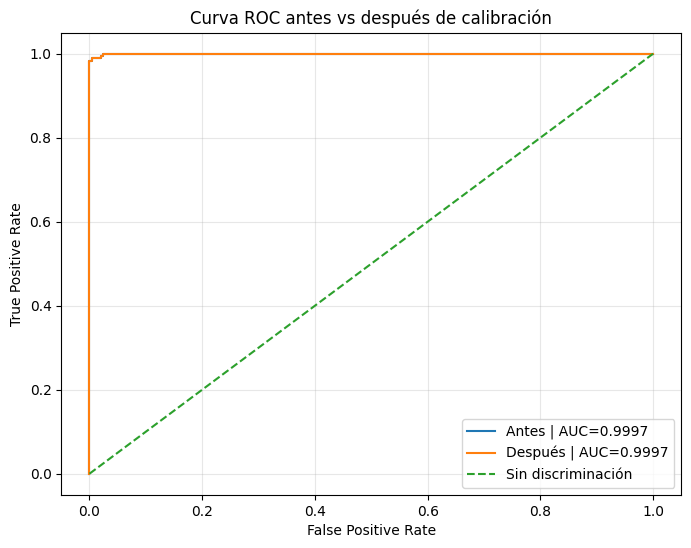

In [ ]:
fpr_before, tpr_before, _ = roc_curve(
    y_true_test_cal,
    y_prob_test_before
)

fpr_after, tpr_after, _ = roc_curve(
    y_true_cal,
    y_prob_after
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_before,
    tpr_before,
    label=f"Antes | AUC={roc_auc_score(y_true_test_cal, y_prob_test_before):.4f}"
)

plt.plot(
    fpr_after,
    tpr_after,
    label=f"Después | AUC={test_auc_cal:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Sin discriminación"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC antes vs después de calibración")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 8.6. Interpretación

El ejercicio cumple dos componentes distintos:

**1. Calibración de probabilidades**

Se implementa Temperature Scaling y la temperatura se aprende únicamente con VALIDATION. En la ejecución actual se obtuvo \(T approx 0.8854\), lo que modifica la confianza de las probabilidades sin reentrenar la CNN.

**2. Análisis de la curva ROC**

Se comparan las curvas ROC antes y después de calibrar. Ambas presentan un ROC-AUC aproximado de **0.9997**, resultado esperado porque Temperature Scaling conserva el orden de las puntuaciones.

La conclusión adecuada es:

> Temperature Scaling modificó la confianza probabilística del modelo manteniendo su capacidad discriminativa. La superposición de las curvas ROC es esperable y no constituye un error, ya que la calibración no busca aumentar el ROC-AUC.

No debe afirmarse que la calibración “mejoró” solo porque se aplicó Temperature Scaling; para demostrar una mejora cuantitativa de calibración sería necesario incorporar una métrica específica adicional. El objetivo solicitado por el profesor —implementar calibración y analizar la ROC— sí queda desarrollado en esta sección.

## 9. Transfer Learning

Se utilizará **ResNet18 preentrenada en ImageNet**.

El proceso tendrá dos etapas:

1. Entrenar únicamente la nueva capa de clasificación.
2. Descongelar `layer4` y el clasificador para realizar fine-tuning.

### 9.1. Preparar datos para ResNet18

In [ ]:
imagenet_mean = (
    0.485,
    0.456,
    0.406
)

imagenet_std = (
    0.229,
    0.224,
    0.225
)

transform_tl_train = T.Compose([
    T.Resize((224, 224)),

    T.RandomRotation(
        degrees=8
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.97, 1.03)
    ),

    T.ToTensor(),

    T.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        imagenet_mean,
        imagenet_std
    )
])

train_base_tl = DataClass(
    split="train",
    transform=transform_tl_train,
    download=True
)

val_base_tl = DataClass(
    split="val",
    transform=transform_tl_eval,
    download=True
)

test_base_tl = DataClass(
    split="test",
    transform=transform_tl_eval,
    download=True
)

train_dataset_tl, _ = get_binary_subset(
    train_base_tl,
    selected_original_classes
)

val_dataset_tl, _ = get_binary_subset(
    val_base_tl,
    selected_original_classes
)

test_dataset_tl, _ = get_binary_subset(
    test_base_tl,
    selected_original_classes
)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

train_eval_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

xb_tl, yb_tl = next(
    iter(train_loader_tl)
)

print(
    "Batch Transfer Learning:",
    xb_tl.shape
)

Batch Transfer Learning: torch.Size([64, 3, 224, 224])


### 9.2. Entrenar capa final

Primero se congela el backbone de ResNet18 y se entrena solamente el nuevo clasificador binario.

In [ ]:
# ============================================================
# 9.2 Entrenar capa final - Transfer Learning
# ============================================================

weights = models.ResNet18_Weights.DEFAULT

resnet = models.resnet18(
    weights=weights
)

# ------------------------------------------------------------
# Reemplazar clasificador original por clasificador binario
# ------------------------------------------------------------

in_features = resnet.fc.in_features

resnet.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, 2)
)

# ------------------------------------------------------------
# Congelar todo el backbone de ResNet18
# ------------------------------------------------------------

for param in resnet.parameters():
    param.requires_grad = False

# Entrenar únicamente la nueva capa FC
for param in resnet.fc.parameters():
    param.requires_grad = True

# Enviar modelo al dispositivo
resnet = resnet.to(device)

print("Dispositivo:", device)
print("Entrenando únicamente la capa final de ResNet18...")
print("Épocas máximas: 3")
print("=" * 70)

# ------------------------------------------------------------
# Entrenamiento
# ------------------------------------------------------------

resnet, history_resnet_head = fit_model(
    resnet,
    train_loader_tl,
    val_loader_tl,
    train_eval_loader_tl,
    lr=1e-3,
    scheduler_type="plateau",
    epochs=3,
    patience=1
)

print("=" * 70)
print("Entrenamiento de la capa final terminado.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


Dispositivo: cuda
Entrenando únicamente la capa final de ResNet18...
Épocas máximas: 3
Epoch 01 | train_loss=0.3767 | val_loss=0.1940 | train_acc=0.9598 | val_acc=0.9355 | val_auc=0.9960 | lr=1.00e-03
Epoch 02 | train_loss=0.1761 | val_loss=0.1134 | train_acc=0.9766 | val_acc=0.9747 | val_auc=0.9978 | lr=1.00e-03
Epoch 03 | train_loss=0.1639 | val_loss=0.1258 | train_acc=0.9726 | val_acc=0.9378 | val_auc=0.9982 | lr=1.00e-03
Early stopping activado.
Entrenamiento de la capa final terminado.


### 9.3. Fine-tuning

Se descongelan `layer4` y `fc` para adaptar las últimas representaciones de ResNet18 al dominio de BloodMNIST.

In [ ]:
for name, param in resnet.named_parameters():

    param.requires_grad = (
        name.startswith("layer4")
        or name.startswith("fc")
    )

trainable_params = [
    p for p in resnet.parameters()
    if p.requires_grad
]

optimizer_ft = torch.optim.AdamW(
    trainable_params,
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="min",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

criterion_ft = nn.CrossEntropyLoss()

history_ft = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

best_ft_loss = float("inf")
best_ft_state = copy.deepcopy(
    resnet.state_dict()
)

patience_ft = 0

for epoch in range(1, 7):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer_ft,
        criterion_ft
    )

    val_loss = evaluate_loss(
        resnet,
        val_loader_tl,
        criterion_ft
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    scheduler_ft.step(
        val_loss
    )

    current_lr = (
        optimizer_ft.param_groups[0]["lr"]
    )

    history_ft["train_loss"].append(
        train_loss
    )

    history_ft["val_loss"].append(
        val_loss
    )

    history_ft["val_acc"].append(
        val_acc
    )

    history_ft["val_auc"].append(
        val_auc
    )

    history_ft["lr"].append(
        current_lr
    )

    print(
        f"Fine-tuning Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_loss < best_ft_loss - 1e-4:

        best_ft_loss = val_loss

        best_ft_state = copy.deepcopy(
            resnet.state_dict()
        )

        patience_ft = 0

    else:

        patience_ft += 1

    if patience_ft >= 3:

        print(
            "Early stopping del fine-tuning."
        )

        break

resnet.load_state_dict(
    best_ft_state
)

Fine-tuning Epoch 01 | train_loss=0.0477 | val_loss=0.0159 | val_acc=0.9954 | val_auc=0.9999 | lr=1.00e-04
Fine-tuning Epoch 02 | train_loss=0.0209 | val_loss=0.0177 | val_acc=0.9954 | val_auc=0.9997 | lr=1.00e-04
Fine-tuning Epoch 03 | train_loss=0.0161 | val_loss=0.0105 | val_acc=0.9954 | val_auc=0.9999 | lr=1.00e-04
Fine-tuning Epoch 04 | train_loss=0.0081 | val_loss=0.0137 | val_acc=0.9931 | val_auc=0.9999 | lr=1.00e-04
Fine-tuning Epoch 05 | train_loss=0.0079 | val_loss=0.0156 | val_acc=0.9954 | val_auc=0.9999 | lr=5.00e-05
Fine-tuning Epoch 06 | train_loss=0.0062 | val_loss=0.0176 | val_acc=0.9954 | val_auc=0.9999 | lr=5.00e-05
Early stopping del fine-tuning.


<All keys matched successfully>

### 9.4. Evaluación en test

Se reportan:

- Accuracy
- ROC-AUC
- Classification Report
- Matriz de confusión

Transfer Learning - Test Accuracy: 0.9931
Transfer Learning - Test ROC-AUC: 0.9998
Classification Report:
              precision    recall  f1-score   support

    basophil     0.9837    0.9918    0.9878       244
  eosinophil     0.9968    0.9936    0.9952       624

    accuracy                         0.9931       868
   macro avg     0.9903    0.9927    0.9915       868
weighted avg     0.9931    0.9931    0.9931       868

Matriz de confusión:
[[242   2]
 [  4 620]]


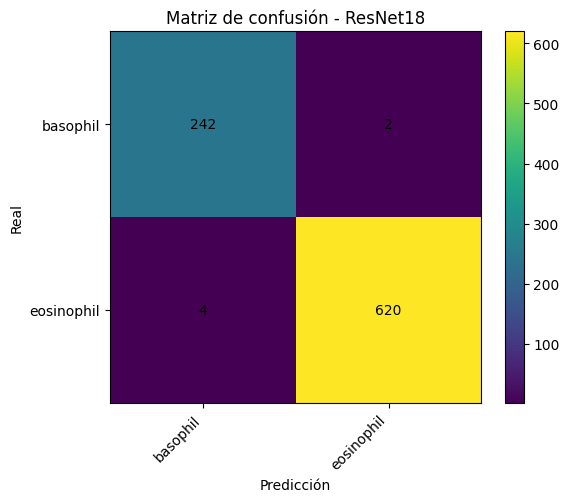

In [ ]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet,
    test_loader_tl
)

print(
    f"Transfer Learning - Test Accuracy: "
    f"{test_acc_tl:.4f}"
)

print(
    f"Transfer Learning - Test ROC-AUC: "
    f"{test_auc_tl:.4f}"
)

print("Classification Report:")

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=class_names,
        digits=4
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

print(
    "Matriz de confusión:"
)

print(cm_tl)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm_tl,
    interpolation="nearest"
)

plt.title(
    "Matriz de confusión - ResNet18"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()

plt.xticks(
    range(2),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(2),
    class_names
)

for i in range(cm_tl.shape[0]):
    for j in range(cm_tl.shape[1]):
        plt.text(
            j,
            i,
            cm_tl[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## 10. Comparación global

Se comparan los resultados obtenidos sobre TEST por:

- Mejor CNN seleccionada mediante VALIDATION.
- ResNet18 con Transfer Learning.

La comparación se presenta descriptivamente mediante Accuracy y ROC-AUC.

In [ ]:
global_results = pd.DataFrame([
    {
        "Modelo": f"Mejor CNN ({best_aug_name})",
        "Accuracy": test_acc_cnn,
        "ROC-AUC": test_auc_cnn
    },
    {
        "Modelo": "ResNet18 + Fine-tuning",
        "Accuracy": test_acc_tl,
        "ROC-AUC": test_auc_tl
    }
])

display(global_results)

,Modelo,Accuracy,ROC-AUC
0,Mejor CNN (Aumento moderado),0.990783,0.999724
1,ResNet18 + Fine-tuning,0.993088,0.999823


## 11. Grad-CAM

Grad-CAM permite visualizar regiones de la imagen que contribuyen a la predicción del modelo.

Para ResNet18 se utiliza la última capa convolucional de `layer4`.

Esta visualización debe interpretarse como una herramienta de apoyo a la interpretabilidad y no como evidencia de causalidad clínica.

/tmp/ipykernel_2321/2843810323.py:126: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"Original | real={int(y_cam)}"


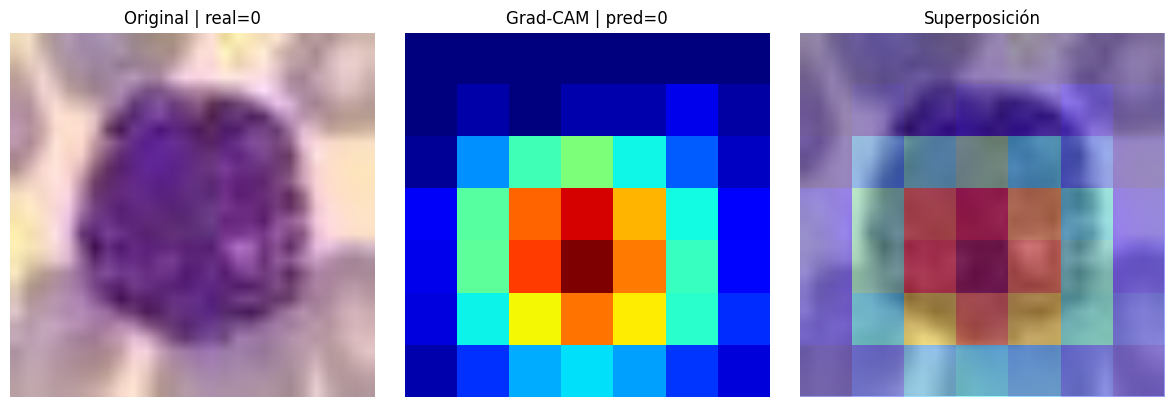

In [ ]:
def grad_cam(
    model,
    image_tensor,
    target_class=None
):

    model.eval()

    activations = {}
    gradients = {}

    target_layer = model.layer4[-1]

    def forward_hook(
        module,
        inp,
        out
    ):
        activations["value"] = out

    def backward_hook(
        module,
        grad_in,
        grad_out
    ):
        gradients["value"] = grad_out[0]

    h1 = target_layer.register_forward_hook(
        forward_hook
    )

    h2 = target_layer.register_full_backward_hook(
        backward_hook
    )

    x = image_tensor.unsqueeze(
        0
    ).to(device)

    logits = model(x)

    if target_class is None:

        target_class = int(
            torch.argmax(
                logits,
                dim=1
            ).item()
        )

    score = logits[
        0,
        target_class
    ]

    model.zero_grad(
        set_to_none=True
    )

    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights_cam = grad.mean(
        dim=(1, 2)
    )

    cam = torch.sum(
        weights_cam[:, None, None] * act,
        dim=0
    )

    cam = torch.relu(cam)

    cam = (
        cam - cam.min()
    )

    cam = cam / (
        cam.max() + 1e-8
    )

    h1.remove()
    h2.remove()

    return (
        cam.detach().cpu().numpy(),
        target_class
    )


idx = 0

x_cam, y_cam = test_dataset_tl[idx]

cam, pred_class = grad_cam(
    resnet,
    x_cam
)

img = (
    x_cam.cpu()
    .permute(1, 2, 0)
    .numpy()
)

img = (
    img * np.array(imagenet_std)
    + np.array(imagenet_mean)
)

img = np.clip(
    img,
    0,
    1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)

plt.imshow(img)

plt.title(
    f"Original | real={int(y_cam)}"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    cam,
    cmap="jet"
)

plt.title(
    f"Grad-CAM | pred={pred_class}"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(img)

plt.imshow(
    cam,
    cmap="jet",
    alpha=0.40,
    extent=(
        0,
        img.shape[1],
        img.shape[0],
        0
    )
)

plt.title(
    "Superposición"
)

plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Buenas prácticas

1. Mantener una separación estricta entre TRAIN, VALIDATION y TEST.
2. No utilizar TEST para seleccionar arquitectura, learning rate, scheduler o Data Augmentation.
3. Comparar experimentos bajo condiciones equivalentes para atribuir correctamente el efecto del cambio realizado.
4. No asumir que Dropout, un scheduler o un aumento más fuerte necesariamente mejoran el modelo; deben evaluarse experimentalmente.
5. Reportar Accuracy junto con ROC-AUC y matriz de confusión.
6. Distinguir **discriminación** de **calibración**: ROC-AUC evalúa capacidad de separación, mientras que Temperature Scaling modifica la confianza probabilística.
7. Revisar posibles sesgos de población, equipo y procedencia de las imágenes.
8. Considerar validación externa cuando sea posible.
9. Grad-CAM ayuda a interpretar el modelo, pero no demuestra causalidad.
10. Fijar semillas y registrar las configuraciones utilizadas.
11. En una aplicación médica real, los resultados experimentales no sustituyen una validación clínica.

## 13. Guardar modelos

Se guardan:

- La mejor CNN seleccionada.
- El modelo ResNet18 con fine-tuning.
- La temperatura aprendida para la calibración.

In [ ]:
os.makedirs(
    "models",
    exist_ok=True
)

torch.save(
    best_cnn_model.state_dict(),
    "models/best_cnn_bloodmnist_2classes.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet18_bloodmnist_2classes.pth"
)

torch.save(
    {
        "temperature": temperature,
        "model_name": best_aug_name
    },
    "models/temperature_scaling_bloodmnist_2classes.pth"
)

print("Modelos guardados:")
print(
    " - models/best_cnn_bloodmnist_2classes.pth"
)
print(
    " - models/resnet18_bloodmnist_2classes.pth"
)
print(
    " - models/temperature_scaling_bloodmnist_2classes.pth"
)

Modelos guardados:
 - models/best_cnn_bloodmnist_2classes.pth
 - models/resnet18_bloodmnist_2classes.pth
 - models/temperature_scaling_bloodmnist_2classes.pth


## 14. Conclusiones

En este notebook se desarrolló un pipeline de clasificación binaria sobre BloodMNIST.

###  Cambio de arquitectura

Se modificó la CNN incorporando **Dropout** y se comparó contra la arquitectura original. La variante con Dropout no superó a la CNN original en esta ejecución, demostrando que una técnica de regularización debe validarse experimentalmente y no asumirse como una mejora automática.

### Learning Rate y Scheduler

Se compararon `LR = 0.001`, `LR = 0.0005` y `LR = 0.001 + StepLR`. Según el criterio implementado de menor Validation Loss, la mejor configuración fue **LR = 0.001 sin scheduler**.

### Data Augmentation

Se estudiaron tres escenarios: **sin aumento, aumento suave y aumento moderado**. La selección se realizó con Validation ROC-AUC y la configuración elegida fue **aumento moderado**, aunque las diferencias frente a las otras configuraciones fueron pequeñas y no fue superior en todas las métricas.

###  Calibración y curva ROC

Se implementó **Temperature Scaling**, aprendiendo la temperatura exclusivamente con VALIDATION. La temperatura obtenida fue aproximadamente `0.8854`. La Accuracy y el ROC-AUC permanecieron prácticamente iguales antes y después, lo cual es coherente porque Temperature Scaling modifica la confianza probabilística sin alterar la capacidad discriminativa del modelo. Las curvas ROC se compararon explícitamente.

### Criterio metodológico general

Las configuraciones de arquitectura, learning rate, scheduler y Data Augmentation se seleccionaron utilizando **VALIDATION**, mientras que **TEST se reservó para la evaluación final**. De esta forma, los experimentos responden directamente a los ejercicios solicitados y sus conclusiones se basan en las métricas realmente calculadas por el notebook.